In [1]:
import json
import datetime
from IPython.display import Markdown, display

from openagri_benchmark.postprocessing.usecases import (
    UseCaseB,
)

from openagri_benchmark.postprocessing.utils import (
    plot_use_case_processing_energy_by_step,
    plot_use_case_total_energy_by_setup
)

In [2]:
use_case_b_results = {}
for setup in ['edge', 'cloud']:
    setup_res = UseCaseB(
        base_workload='low',
        deployment_setup=setup, 
        tasks_profiling_id='test_profile'
    ).run()
    use_case_b_results[setup] = setup_res
    
display(Markdown(UseCaseB.get_markdown_of_usecase_steps(use_case_b_results['cloud'])))

# UseCaseB

Use Case B — Irrigation workflow for irrigated field crops (Farm Calendar, Irrigation Service, Weather Service, Reporting Service)

A micro SME with expertise in ICT is located in a rural area in Poland and wants to get into the smart agriculture business.
Given the increasing frequency of droughts in the region, they decided to collaborate with local farm advisors and to offer
  digital services to irrigated-field farmers, including recording of farm management practices, decision support on irrigation timing and dose,
  and reporting about water use. They have a new contract with a local farmers cooperative.

We consider a low workload for this use case, with very sparse brust of medium workload use case,
    where the cooperative has 30 members/farmers and each farmer manages 5 parcels.
Each parcel covers an area from 1–5 hectares.

The irrigation season runs from crop establishment to harvest, roughly March–October depending on the crop (e.g., potatoes, sugar beet, maize) and the intended use.

The initial date is set for the last day of February (one day to setup all the services and register farms, parcels and crops) and
    the final date is set for the first day of November, after the harvest and reporting.

## 1: 1Day-Feb

| Service | Task | Workload | Repetition | Description |
|---|---|---|---|---|
| farmcalendar | register_farm | low | 30 | Register one farm per farmer account. |
| farmcalendar | register_parcel | low | 150 | Register 5 parcels per farm. |
| farmcalendar | register_crop | low | 150 | Register the crop on each parcel (potatoes, sugar beet, maize, vegetables). |
| farmcalendar | register_activity_type | low | 4 | Creating new generic activity types specific for the use case. |
| farmcalendar | filter_parcels | low | 600 | Farmer selects a parcel from their list to view its details. |
| farmcalendar | monthly_activities | low | 300 | Farmer opens the monthly calendar view for a parcel. |
| farmcalendar | get_activity | low | 600 | Farmer opens detail view of a specific calendar activity. |



## Processing Energy UseCase

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Processing Energy Consumption Throughout Use Case b'}, ylabel='Processing Energy (Wh)'>)

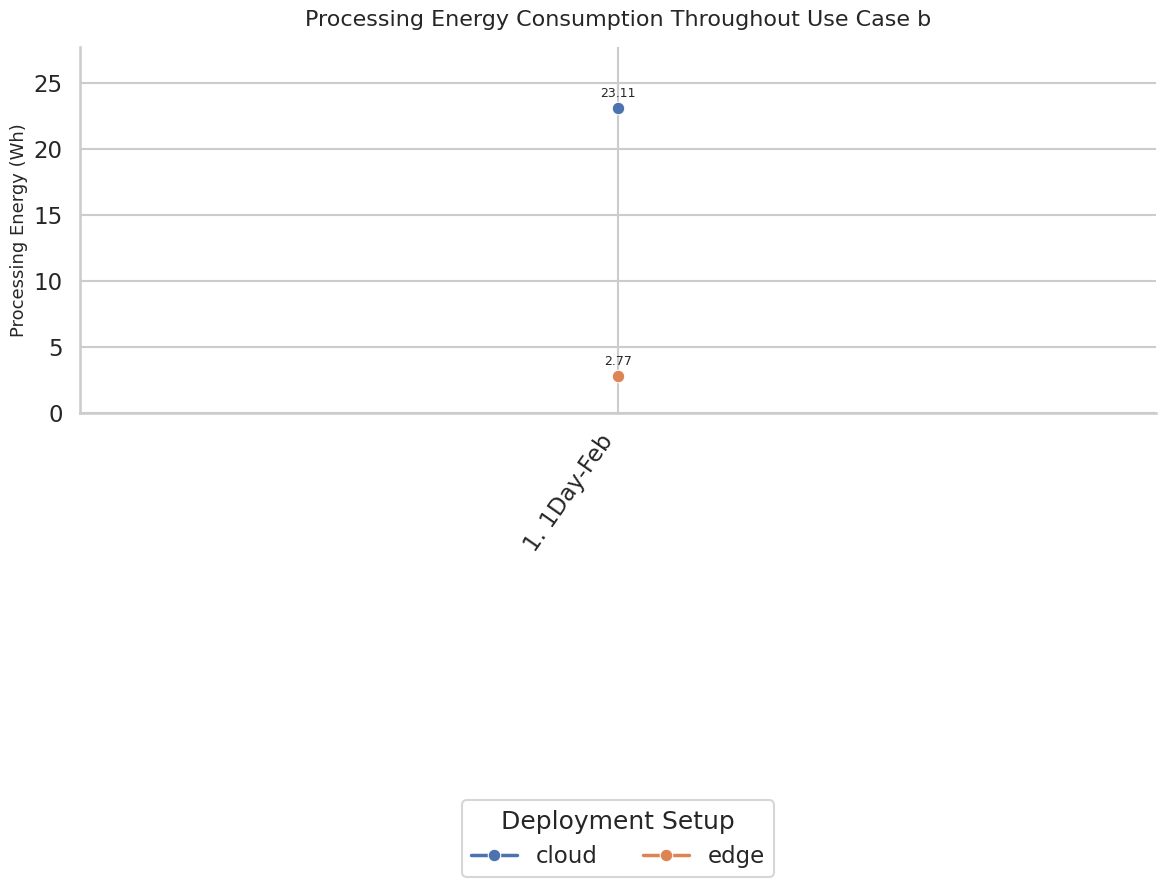

In [3]:
plot_use_case_processing_energy_by_step(use_case_b_results, use_case='b') 

## Total Energy for UseCase

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Total Energy Consumption per Deployment Setup - Use Case B'}, xlabel='Deployment Setup', ylabel='Total Energy (kWh)'>)

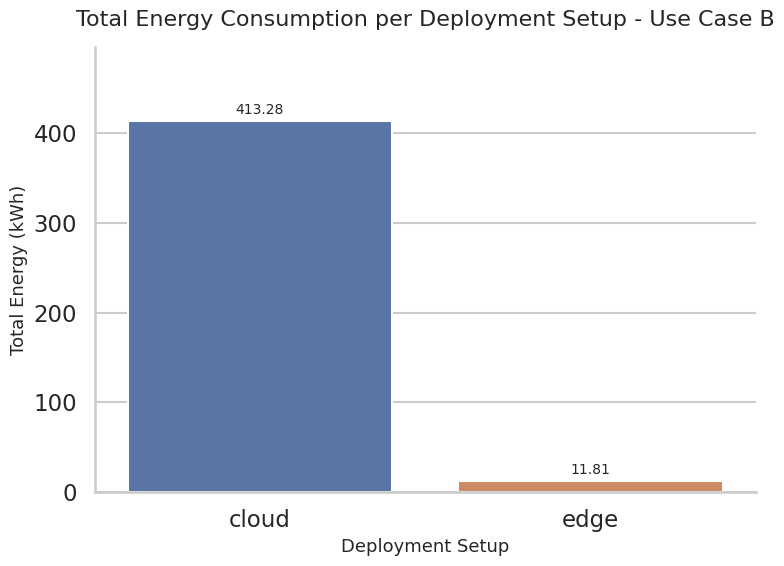

In [4]:
plot_use_case_total_energy_by_setup(use_case_b_results, use_case="B")